**Equipe:**
- Matheus Virgolino Abilio da Silva - 124210975
- Jefferson Ribeiro Brasil - 123110470
- João Gabriel Eulálio Luiggi Ramos - 121110737
- José Vitor Barbosa Maciel - 120210954
- Pedro Wilson Silva de Sousa - 124211096

# EDA e Pré-processamento: Dados de Mobilidade

Este notebook aborda a análise exploratória e o pré-processamento do conjunto de dados de telemetria GPS para o desafio NetMob 2026.

**Objetivos:**
- Carregar e concatenar os arquivos CSV diários de mobilidade.
- Limpar os dados (tratar valores nulos, corrigir tipos de dados, filtrar coordenadas inválidas).
- Extrair features temporais.
- Calcular métricas operacionais: **Headway** (intervalo entre ônibus) e **Velocidade Comercial**.
- Explorar a relação entre as próprias variáveis operacionais (ex: velocidade vs. hora do dia, velocidade vs. headway).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregamento dos Dados
O conjunto de dados de mobilidade consiste em 19 arquivos CSV diários (~1.7 GB no total). Usaremos `glob` para encontrar todos os arquivos e concatená-los.

In [8]:
# Definir o caminho para o diretorio de dados de mobilidade
mobility_path = '../data/mobility_data/*.csv'
all_files = glob.glob(mobility_path)

print(f"Encontrados {len(all_files)} arquivos.")

# Carregar e concatenar todos os arquivos
df_list = []
for filename in all_files:
    df_temp = pd.read_csv(filename)
    df_list.append(df_temp)

df_mobility = pd.concat(df_list, axis=0, ignore_index=True)
print(f"Total de registros carregados: {len(df_mobility):,}")

# Exibir informacoes basicas
display(df_mobility.info())
display(df_mobility.head())

Encontrados 19 arquivos.
Total de registros carregados: 13,553,096
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13553096 entries, 0 to 13553095
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   timestamp  object 
 2   tripId     object 
 3   lat        float64
 4   lng        float64
 5   heading    float64
 6   lineId     object 
 7   lineName   object 
 8   headsign   object 
 9   direction  int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 1.0+ GB


None

,id,timestamp,tripId,lat,lng,heading,lineId,lineName,headsign,direction
0,52243,2026-03-11 00:00:07,1476582_U_37,-22.875029,-43.038486,322.00000,52,BALDEADOR X ITAIPU (VIA CANTAGALO),52 BALDEADOR,1
1,52272,2026-03-11 00:00:07,1483711_U_195,-22.912451,-43.078884,92.60256,33,JURUJUBA X TERMINAL RODOVIARIO,33 TERMINAL RODOVIÁRIO,0
2,69020,2026-03-11 00:00:07,1345046_U_36,-22.890236,-43.124805,352.20000,39A,PIRATININGA X CENTRO,39A Piratininga (Cafubá),1
3,69050,2026-03-11 00:00:07,1393827_U_152,-22.895660,-43.124977,236.50000,45,CUBANGO X CENTRO,45 Cubango,1
4,69121,2026-03-11 00:00:07,1414833_U_72,-22.932734,-43.098888,50.30000,OC1,OCEÂNICA 1,OC1 Piratininga,1


## 2. Pré-processamento
Nesta etapa, iremos:
1. **Converter Tipos de Dados**: Garantir que `timestamp` seja um objeto datetime.
2. **Tratar Valores Nulos**: Remover linhas com informações cruciais ausentes (`lat`, `lng`, `lineId`, `direction`).
3. **Filtrar Coordenadas Inválidas**: Manter apenas os registros dentro do bounding box da cidade de Niterói.
4. **Extrair Features Temporais**: Extrair a data, hora e o dia da semana para agrupar análises.

In [9]:
# 1. Converter timestamp (ja esta em BRT UTC-3, sem necessidade de localizacao de timezone para operacoes basicas)
df_mobility['timestamp'] = pd.to_datetime(df_mobility['timestamp'])

# 2. Tratar valores nulos
initial_len = len(df_mobility)
df_mobility = df_mobility.dropna(subset=['lat', 'lng', 'lineId', 'direction', 'id', 'timestamp'])
print(f"Foram removidas {initial_len - len(df_mobility):,} linhas com valores nulos em colunas chave.")

# Garantir que lineId e direction sejam string e direction seja inteiro
df_mobility['lineId'] = df_mobility['lineId'].astype(str)
df_mobility['direction'] = df_mobility['direction'].astype(int)

# 3. Filtrar coordenadas (Bounding Box de Niteroi: Lat [-22.95, -22.75], Lng [-43.20, -42.95])
lat_mask = (df_mobility['lat'] >= -22.95) & (df_mobility['lat'] <= -22.75)
lng_mask = (df_mobility['lng'] >= -43.20) & (df_mobility['lng'] <= -42.95)
df_mobility = df_mobility[lat_mask & lng_mask]
print(f"Registros restantes apos filtro espacial: {len(df_mobility):,}")

# 4. Extrair features temporais
df_mobility['date'] = df_mobility['timestamp'].dt.date
df_mobility['hour'] = df_mobility['timestamp'].dt.hour
df_mobility['day_of_week'] = df_mobility['timestamp'].dt.dayofweek
df_mobility['is_weekend'] = df_mobility['day_of_week'].isin([5, 6]).astype(int)

display(df_mobility[['timestamp', 'date', 'hour', 'day_of_week', 'is_weekend']].head())

Foram removidas 0 linhas com valores nulos em colunas chave.
Registros restantes apos filtro espacial: 13,158,542


,timestamp,date,hour,day_of_week,is_weekend
0,2026-03-11 00:00:07,2026-03-11,0,2,0
1,2026-03-11 00:00:07,2026-03-11,0,2,0
2,2026-03-11 00:00:07,2026-03-11,0,2,0
3,2026-03-11 00:00:07,2026-03-11,0,2,0
4,2026-03-11 00:00:07,2026-03-11,0,2,0


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Veículos Ativos ao Longo do Tempo
Vamos observar quantos ônibus distintos operam por dia e por hora da operação.

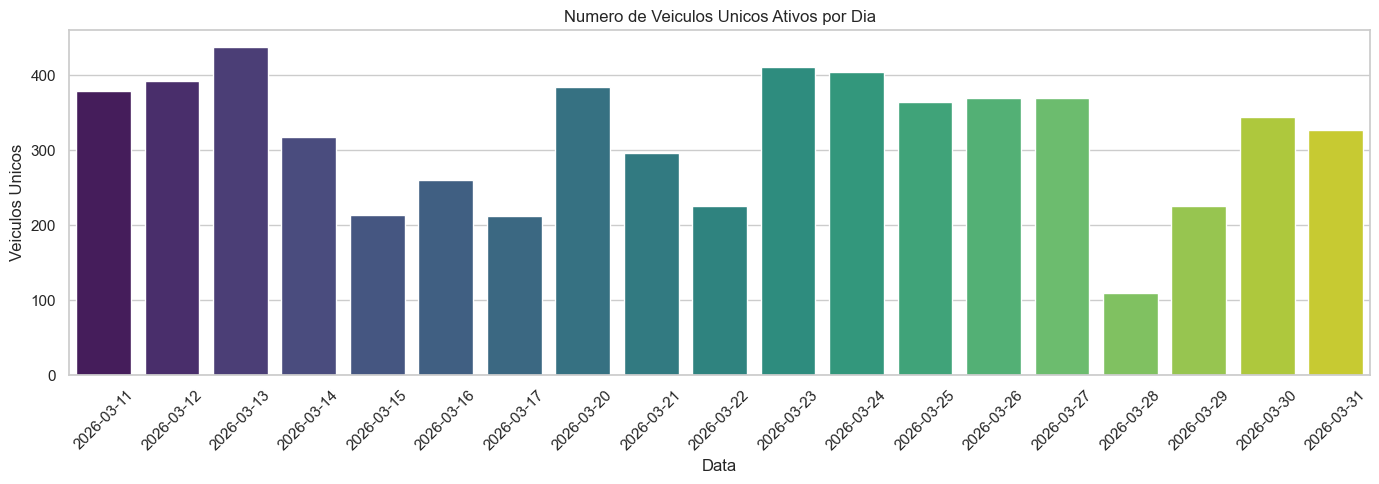

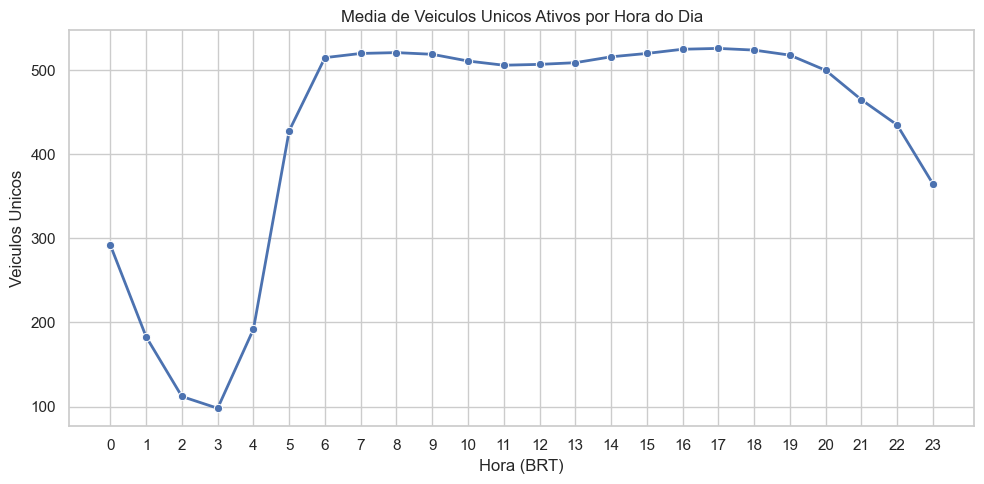

In [10]:
# Veiculos ativos por dia
daily_active = df_mobility.groupby('date')['id'].nunique().reset_index()

plt.figure(figsize=(14, 5))
sns.barplot(data=daily_active, x='date', y='id', palette='viridis')
plt.title('Numero de Veiculos Unicos Ativos por Dia')
plt.ylabel('Veiculos Unicos')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Veiculos ativos por hora do dia
hourly_active = df_mobility.groupby('hour')['id'].nunique().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_active, x='hour', y='id', marker='o', linewidth=2)
plt.title('Media de Veiculos Unicos Ativos por Hora do Dia')
plt.ylabel('Veiculos Unicos')
plt.xlabel('Hora (BRT)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 3.2 Cálculo de Headway (Intervalo)
O headway é o intervalo de tempo entre dois ônibus consecutivos na mesma linha e mesma direção.
Calculamos isso ordenando os dados e encontrando a diferença de tempo quando o ID do veículo muda, para um mesmo grupo de linha e direção.

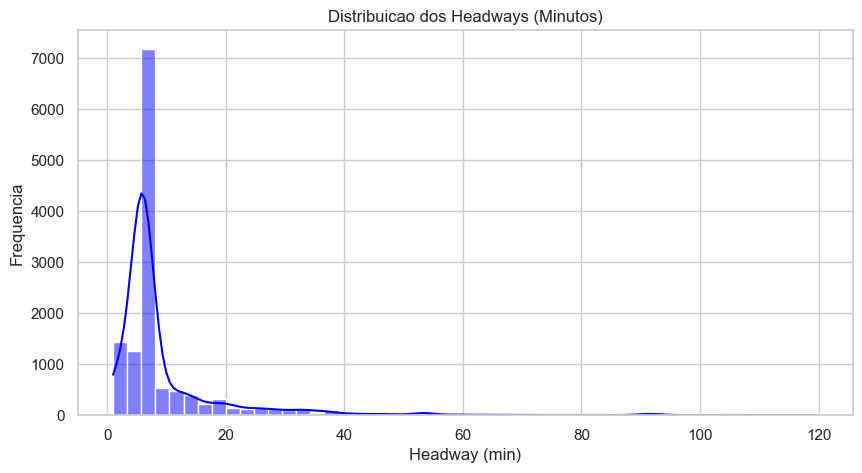

Headway Mediano Geral: 5.98 minutos


In [11]:
# Ordenar os dados para calcular o headway de forma confiavel
df_mobility.sort_values(by=['lineId', 'direction', 'id', 'timestamp'], inplace=True)

# Uma proxy simples para o headway: agrupar por linha e direcao, ordenar por tempo e medir a diferenca
# entre observacoes consecutivas de veiculos *diferentes*.
df_sorted = df_mobility.sort_values(by=['lineId', 'direction', 'timestamp']).copy()

# Encontrar o momento em que o ID do veiculo muda para a mesma linha e direcao
df_sorted['prev_id'] = df_sorted.groupby(['lineId', 'direction'])['id'].shift(1)
df_sorted['prev_timestamp'] = df_sorted.groupby(['lineId', 'direction'])['timestamp'].shift(1)

# Manter apenas os registros que representam uma mudanca de veiculo
df_headway = df_sorted[df_sorted['id'] != df_sorted['prev_id']].copy()

# Calcular headway em minutos
df_headway['headway_min'] = (df_headway['timestamp'] - df_headway['prev_timestamp']).dt.total_seconds() / 60.0

# Filtrar headways plausiveis (ex: entre 1 e 120 minutos, para descartar fins de operacao)
df_headway_clean = df_headway[(df_headway['headway_min'] >= 1) & (df_headway['headway_min'] <= 120)]

plt.figure(figsize=(10, 5))
sns.histplot(df_headway_clean['headway_min'], bins=50, kde=True, color='blue')
plt.title('Distribuicao dos Headways (Minutos)')
plt.xlabel('Headway (min)')
plt.ylabel('Frequencia')
plt.show()

print(f"Headway Mediano Geral: {df_headway_clean['headway_min'].median():.2f} minutos")

### 3.3 Cálculo da Velocidade Comercial
Podemos estimar a velocidade comercial dos ônibus usando a distância de Haversine entre pontos sucessivos de GPS do *mesmo* veículo.

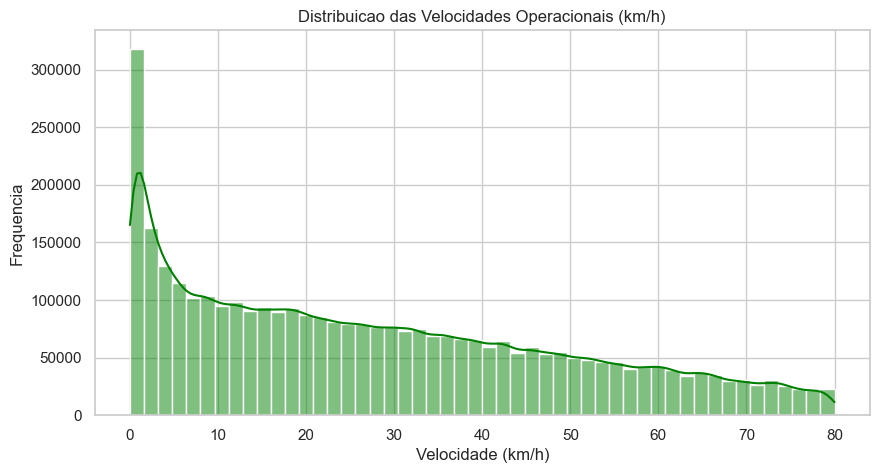

Velocidade Mediana Geral: 24.01 km/h


In [12]:
def haversine(lat1, lon1, lat2, lon2):
    # Raio da Terra em km
    R = 6371.0
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Ordenar por ID do veiculo e tempo para garantir continuidade de trajeto
df_speed = df_mobility.sort_values(by=['id', 'timestamp']).copy()

# Deslocar coordenadas e tempo para calcular os deltas do trecho percorrido
df_speed['prev_lat'] = df_speed.groupby('id')['lat'].shift(1)
df_speed['prev_lng'] = df_speed.groupby('id')['lng'].shift(1)
df_speed['prev_timestamp'] = df_speed.groupby('id')['timestamp'].shift(1)

# Calcular a distancia em km e o delta de tempo em horas
df_speed['dist_km'] = haversine(df_speed['prev_lat'], df_speed['prev_lng'], df_speed['lat'], df_speed['lng'])
df_speed['time_delta_h'] = (df_speed['timestamp'] - df_speed['prev_timestamp']).dt.total_seconds() / 3600.0

# Calcular velocidade (km/h) - usando np.where para evitar divisao por zero
df_speed['speed_kmh'] = np.where(df_speed['time_delta_h'] > 0, df_speed['dist_km'] / df_speed['time_delta_h'], 0)

# Filtrar velocidades validas (ex: > 0 e <= 80 km/h) para remover ruidos comuns em registros GPS
df_speed_clean = df_speed[(df_speed['speed_kmh'] > 0) & (df_speed['speed_kmh'] <= 80)]

plt.figure(figsize=(10, 5))
sns.histplot(df_speed_clean['speed_kmh'], bins=50, kde=True, color='green')
plt.title('Distribuicao das Velocidades Operacionais (km/h)')
plt.xlabel('Velocidade (km/h)')
plt.ylabel('Frequencia')
plt.show()

print(f"Velocidade Mediana Geral: {df_speed_clean['speed_kmh'].median():.2f} km/h")

## 4. Correlações entre Variáveis de Mobilidade
Nesta etapa, focamos na relação entre as próprias variáveis operacionais (desempenho). Vamos agregar os dados por hora e investigar se existe uma correlação direta entre o número de veículos ativos, a velocidade da operação e o headway.

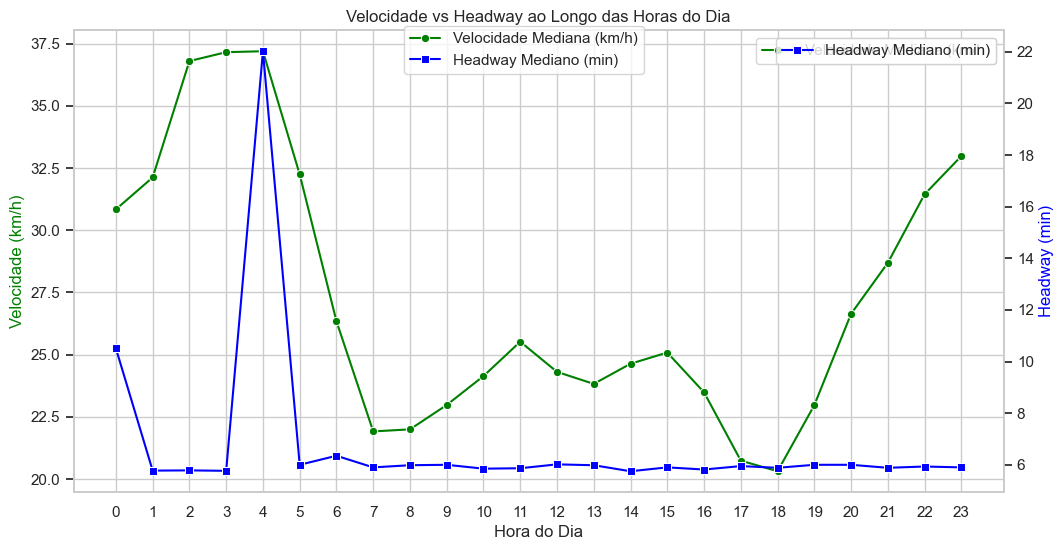

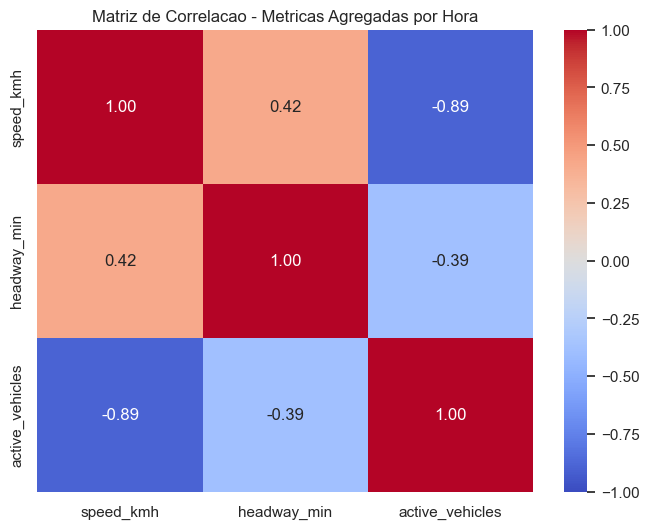

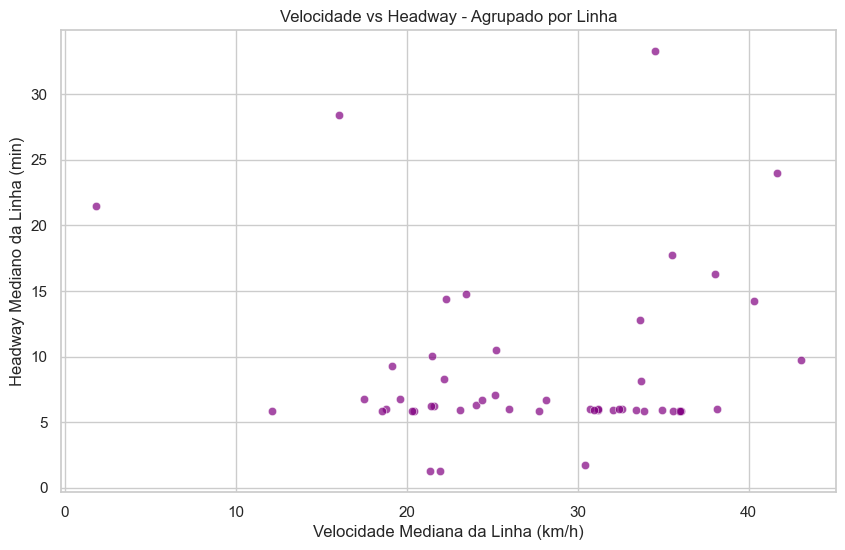

In [13]:
# Agregar Headway e Velocidade Mediana por Hora do Dia
hourly_headway = df_headway_clean.groupby('hour')['headway_min'].median().reset_index()
hourly_speed = df_speed_clean.groupby('hour')['speed_kmh'].median().reset_index()

# Juntar as metricas horarias em um unico DataFrame com o numero de veiculos ativos
hourly_metrics = hourly_headway.merge(hourly_speed, on='hour').merge(hourly_active, on='hour')
hourly_metrics.rename(columns={'id': 'active_vehicles'}, inplace=True)

# Grafico 1: Velocidade vs Headway ao Longo do Dia
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
sns.lineplot(data=hourly_metrics, x='hour', y='speed_kmh', ax=ax1, color='green', marker='o', label='Velocidade Mediana (km/h)')
sns.lineplot(data=hourly_metrics, x='hour', y='headway_min', ax=ax2, color='blue', marker='s', label='Headway Mediano (min)')

ax1.set_xlabel('Hora do Dia')
ax1.set_ylabel('Velocidade (km/h)', color='green')
ax2.set_ylabel('Headway (min)', color='blue')
ax1.set_xticks(range(0, 24))

plt.title('Velocidade vs Headway ao Longo das Horas do Dia')
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.9))
plt.grid(False) # desativa grid secundario para nao poluir a visualizacao
plt.show()

# Grafico 2: Matriz de Correlacao - Metricas Operacionais
corr_matrix = hourly_metrics[['speed_kmh', 'headway_min', 'active_vehicles']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlacao - Metricas Agregadas por Hora')
plt.show()

# Grafico 3: Dispersao (Scatter) Velocidade vs Headway Agrupado por Linha
# Aggregation by lineId to see if slower lines have generally longer or shorter headways
line_metrics = df_headway_clean.groupby('lineId')['headway_min'].median().reset_index().merge(
    df_speed_clean.groupby('lineId')['speed_kmh'].median().reset_index(), on='lineId'
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=line_metrics, x='speed_kmh', y='headway_min', alpha=0.7, color='purple')
plt.title('Velocidade vs Headway - Agrupado por Linha')
plt.xlabel('Velocidade Mediana da Linha (km/h)')
plt.ylabel('Headway Mediano da Linha (min)')
plt.show()